# Подключение Google Drive и проверка структуры каталогов датасета.

In [3]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
import random
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import torch.nn as nn

 # Фиксация случайности

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [6]:
import os
print(os.listdir('/content/drive/MyDrive/'))
print(os.listdir('/content/drive/MyDrive/ИТМО/'))
print(os.listdir('/content/drive/MyDrive/ИТМО/sobes/'))
print(os.listdir('/content/drive/MyDrive/ИТМО/sobes/EyesDataset/'))


['Робот завязывающий шнурки', 'Проект Робо-Урна', 'porfolio.com', 'Сириус Лето', 'wwwgrand1', 'СириусСайт2', 'Достижения', 'ArtemBotsman.com', 'ArtemBotsman', 'Дамир', 'feedback-form-master', 'math', 'project', 'Colab Notebooks', 'practice', 'АГУ', 'Этап 1.gdoc', 'Google Планета Земля', 'Контакты', 'Боцман Артем.jpeg', 'БОЦМАН АРТЕМ.jpeg', 'Новая таблица.gsheet', 'Люди.xlsx', 'ИТМО']
['sobes']
['EyesDataset', 'Копия project.ipynb']
['opened', 'closed']


In [7]:
base_dir = '/content/drive/MyDrive/ИТМО/sobes/EyesDataset'
print('Состав каталога:', os.listdir(base_dir))
print('Открытые:', os.listdir(os.path.join(base_dir, 'opened'))[:5])
print('Закрытые:', os.listdir(os.path.join(base_dir, 'closed'))[:5])


Состав каталога: ['opened', 'closed']
Открытые: ['003035.jpg', '001548.jpg', '001258.jpg', '000905.jpg', '001079.jpg']
Закрытые: ['002851.jpg', '003632.jpg', '000517.jpg', '001614.jpg', '001787.jpg']


# Визуальный осмотр нескольких открытых/закрытых глаз (контроль качества данных).

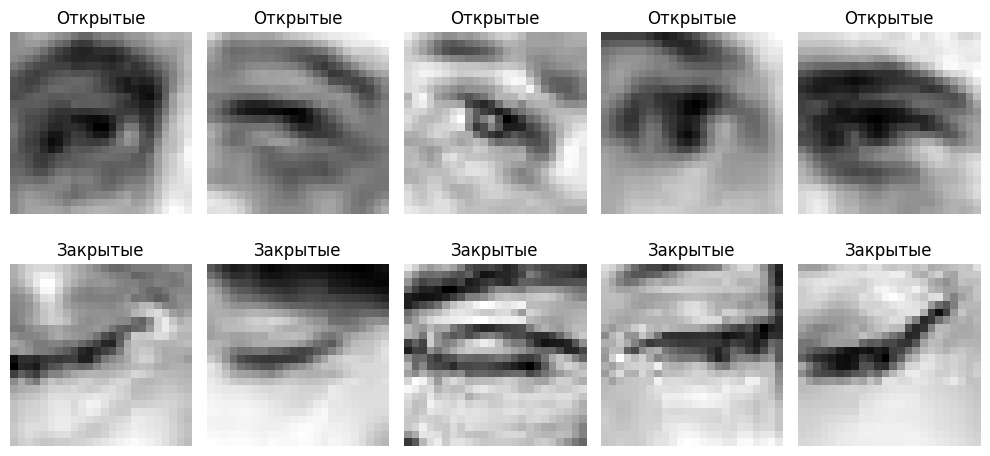

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

open_imgs = os.listdir(os.path.join(base_dir, 'opened'))
closed_imgs = os.listdir(os.path.join(base_dir, 'closed'))

fig, axs = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    img_open = Image.open(os.path.join(base_dir, 'opened', open_imgs[i])).convert('L')
    axs[0, i].imshow(img_open, cmap='gray')
    axs[0, i].set_title('Oткрытые')
    axs[0, i].axis('off')
    img_closed = Image.open(os.path.join(base_dir, 'closed', closed_imgs[i])).convert('L')
    axs[1, i].imshow(img_closed, cmap='gray')
    axs[1, i].set_title('Закрытые')
    axs[1, i].axis('off')
plt.tight_layout()
plt.show()


Создадим датасет для обучения и валидации через ImageFolder

Проверим и после удалим


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Настроим аугментации и преобразования
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((24, 24)),
    transforms.ToTensor(),
])
# Создаем полноценный датасет
dataset = datasets.ImageFolder(base_dir, transform=transform)
print("Классы:", dataset.classes) # ['closed', 'opened'] — в таком порядке
print("Всего изображений:", len(dataset)) # должно совпадать с суммой файлов



Классы: ['closed', 'opened']
Всего изображений: 3815


Разделим на обучающий и валидационный (80/20) чтобы гарантировать одинаковое соотношение - получим индексы изображений каждого класса


In [10]:
from sklearn.model_selection import train_test_split

targets = [label for _, label in dataset.samples]
indices = list(range(len(dataset)))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

from torch.utils.data import Subset
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)


In [11]:
import numpy as np

targets = np.array(targets)
# оставил те же метки, что для stratify

all_counts = np.bincount(targets)
train_counts = np.bincount(targets[train_idx])
val_counts = np.bincount(targets[val_idx])

print("Всего по классам [closed, opened]:", all_counts)
print("Train по классам [closed, opened]:", train_counts)
print("Val по классам [closed, opened]:", val_counts)

print()
print("Доли в общем датасете:", all_counts / all_counts.sum())
print("Доли в train:", train_counts / train_counts.sum())
print("Доли в val:", val_counts / val_counts.sum())


Всего по классам [closed, opened]: [1878 1937]
Train по классам [closed, opened]: [1502 1550]
Val   по классам [closed, opened]: [376 387]

Доли в общем датасете: [0.49226737 0.50773263]
Доли в train: [0.4921363 0.5078637]
Доли в val: [0.49279161 0.50720839]


Весь датасет:

~49.23% closed

~50.77% opened

Train:

~49.21% closed

~50.79% opened

Val:

~49.28% closed

~50.72% opened

Создадим DataLoader

In [12]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)


Проверяем работоспособность

In [13]:
imgs, labels = next(iter(train_loader))
print("Форма батча:", imgs.shape) # [batch, 1, 24, 24]
print("Классы в батче:", labels[:10])


Форма батча: torch.Size([32, 1, 24, 24])
Классы в батче: tensor([0, 0, 1, 1, 0, 1, 1, 0, 1, 1])


архитектура BetterEyeCNN с тремя Conv-слоями и Dropout

Настрой критерий, оптимизатор, число эпох

In [14]:
import torch

print("CUDA доступен:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Используемое устройство:", device)

if device.type == 'cuda':
    print("Название GPU:", torch.cuda.get_device_name(0))
    print("Выделено памяти:", round(torch.cuda.memory_allocated(0)/1024**3, 2), "GB")
    print("Зарезервировано памяти:", round(torch.cuda.memory_reserved(0)/1024**3, 2), "GB")
else:
    print("GPU не используется, работа идёт на CPU.")


CUDA доступен: False
Используемое устройство: cpu
GPU не используется, работа идёт на CPU.


Обучение

#"sanity check" - этот эксперимент использовался только для проверки обучаемости модели на маленьком наборе

In [15]:

'''from collections import defaultdict
from torch.utils.data import Subset

# соберём индексы по каждому классу
class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(dataset.samples):
    class_to_indices[label].append(idx)

small_indices = []
for label, idxs in class_to_indices.items():
    idxs = idxs[:50]     # берём первые 50 этого класса
    small_indices.extend(idxs)

small_train_set = Subset(dataset, small_indices)
small_train_loader = DataLoader(small_train_set, batch_size=16, shuffle=True)
print("Размер маленького train:", len(small_train_set))  # должно быть ~100
'''



'from collections import defaultdict\nfrom torch.utils.data import Subset\n\n# соберём индексы по каждому классу\nclass_to_indices = defaultdict(list)\nfor idx, (_, label) in enumerate(dataset.samples):\n    class_to_indices[label].append(idx)\n\nsmall_indices = []\nfor label, idxs in class_to_indices.items():\n    idxs = idxs[:50]     # берём первые 50 этого класса\n    small_indices.extend(idxs)\n\nsmall_train_set = Subset(dataset, small_indices)\nsmall_train_loader = DataLoader(small_train_set, batch_size=16, shuffle=True)\nprint("Размер маленького train:", len(small_train_set))  # должно быть ~100\n'

-----------------------------------
пробуем на большом датасете ту выборку с err 0.02 из малого датасета

Убедимся, что стоит именно такой transform (как на маленьком опыте,как на маленьком датасете, где всё работало)

один общий transform для train и val. Добавляю аугментацию отдельные transform для train/val - был эксперимент но получил данные хуже
Без аугментации было:

EER(train) ≈ 0.002

EER(val) ≈ 0.0452

С аугментацией:

EER(train) ≈ 0.0153

EER(val) ≈ 0.0559
поэтому принято решение без

Создание датасета и stratified train/val split

In [16]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

base_dir = '/content/drive/MyDrive/ИТМО/sobes/EyesDataset'

# Базовый препроцессинг: перевод в grayscale, приведение к 24x24, тензор.
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((24, 24)),
    transforms.ToTensor(),
])

# Полный датасет с двумя классами: ['closed', 'opened'].
dataset = datasets.ImageFolder(base_dir, transform=transform)
print("Классы:", dataset.classes)
print("Всего изображений:", len(dataset))

# Стратифицированное разбиение на train/val в пропорции 80/20.
targets = [label for _, label in dataset.samples]
indices = list(range(len(dataset)))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

train_set = Subset(dataset, train_idx)
val_set   = Subset(dataset, val_idx)

# DataLoader'ы для обучения и валидации.
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)


Классы: ['closed', 'opened']
Всего изображений: 3815


# Аугментация (flip/rotation) тестировалась отдельно, но ухудшала EER на val,
# поэтому в финальной версии не используется.


MediumEyeCNN - при получении и переобучении. для улучшения можели было принято решение выбрать лучшую эпоху и добавить отслеживание лучшей валидации, где больше Dropout, чуть меньше Linear

# Архитектура MediumEyeCNN: 3 сверточных блока + Dropout + 1 скрытый полносвязный слой.
# Dropout 0.5 и Linear(96) подобраны экспериментально для лучшего баланса train/val EER.
class MediumEyeCNN(nn.Module):
    ...


In [17]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

class MediumEyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Dropout(0.5),                  # было 0.4
            nn.Linear(128 * 3 * 3, 96), nn.ReLU(),  # было 128
            nn.Linear(96, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)



model = MediumEyeCNN().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


device: cpu


train‑loss и val‑loss на каждой эпохе
compute_eer считает EER по loader, модель не изменяет,
compute_loss считает усреднённый BCE‑loss на loader.

In [18]:
import numpy as np
from sklearn.metrics import roc_curve

def compute_eer(loader, name=""):
    model.eval()
    y_true, y_score = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs).cpu().numpy()
            y_true.extend(labels.numpy())
            y_score.extend(outputs.squeeze())
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = fpr[eer_idx]
    print(f"EER ({name}): {eer:.4f}")
    return eer

def compute_loss(loader):
    model.eval()
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            n += imgs.size(0)
    return total_loss / n


# Обучение модели на полном train с отслеживанием лучшей эпохи по EER на валидации.

In [19]:
epochs = 40
best_eer = 1.0
best_state = None

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_set)
    val_loss   = compute_loss(val_loader)
    train_eer_epoch = compute_eer(train_loader, name=f"train epoch {epoch+1}")
    val_eer_epoch   = compute_eer(val_loader,   name=f"val epoch {epoch+1}")

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_EER={train_eer_epoch:.4f} val_EER={val_eer_epoch:.4f}"
    )

    if val_eer_epoch < best_eer:
        best_eer = val_eer_epoch
        best_state = model.state_dict()
        print(f"--> New best EER on val: {best_eer:.4f}")

# после цикла: восстановить лучшую модель
model.load_state_dict(best_state)
print("Best EER on val:", best_eer)

final_train_eer = compute_eer(train_loader, name="train final")
final_val_eer   = compute_eer(val_loader,   name="val final")

torch.save(model.state_dict(), "eye_cnn_best_val.pth")


EER (train epoch 1): 0.0806
EER (val epoch 1): 0.0984
Epoch 1/40 | train_loss=0.3860 val_loss=0.2221 | train_EER=0.0806 val_EER=0.0984
--> New best EER on val: 0.0984
EER (train epoch 2): 0.0439
EER (val epoch 2): 0.0612
Epoch 2/40 | train_loss=0.2072 val_loss=0.1738 | train_EER=0.0439 val_EER=0.0612
--> New best EER on val: 0.0612
EER (train epoch 3): 0.0439
EER (val epoch 3): 0.0559
Epoch 3/40 | train_loss=0.1644 val_loss=0.1893 | train_EER=0.0439 val_EER=0.0559
--> New best EER on val: 0.0559
EER (train epoch 4): 0.0313
EER (val epoch 4): 0.0505
Epoch 4/40 | train_loss=0.1390 val_loss=0.1415 | train_EER=0.0313 val_EER=0.0505
--> New best EER on val: 0.0505
EER (train epoch 5): 0.0320
EER (val epoch 5): 0.0585
Epoch 5/40 | train_loss=0.1482 val_loss=0.1631 | train_EER=0.0320 val_EER=0.0585
EER (train epoch 6): 0.0293
EER (val epoch 6): 0.0426
Epoch 6/40 | train_loss=0.1245 val_loss=0.1390 | train_EER=0.0293 val_EER=0.0426
--> New best EER on val: 0.0426
EER (train epoch 7): 0.0213
EE

# Анализ сложных и простых примеров на валидации:
# собираем предсказания, сортируем по "уверенности" (|p-0.5|),
# визуализируем 5 самых лёгких и 5 самых сложных для модели картинок.


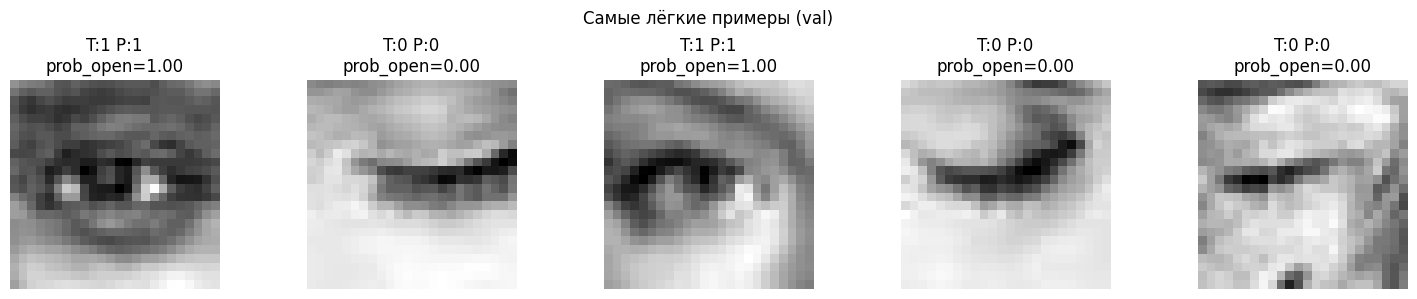

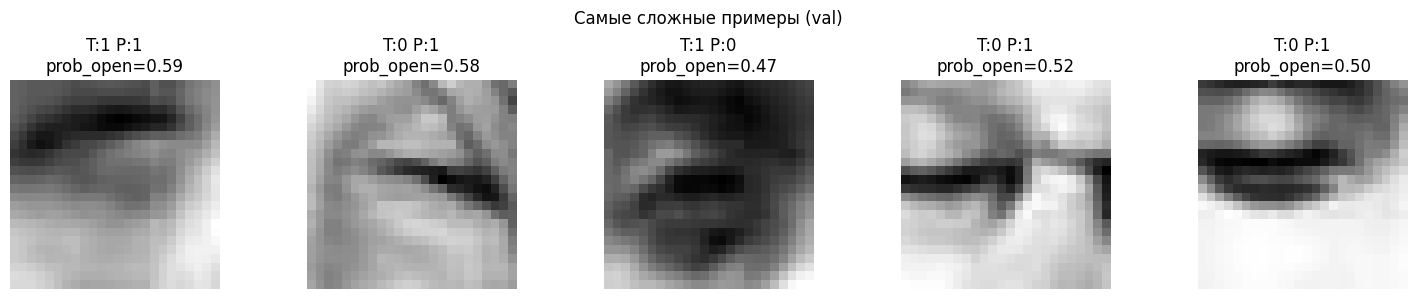

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def collect_examples(loader):
    model.eval()
    examples = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs).cpu().numpy().squeeze()
            labels_np = labels.numpy()
            if outputs.ndim == 0:
                outputs = np.array([outputs])
            for i in range(len(outputs)):
                prob_open = outputs[i]
                pred = 1 if prob_open >= 0.5 else 0
                conf = abs(prob_open - 0.5)  # уверенность
                examples.append((imgs[i].cpu(), labels_np[i], pred, prob_open, conf))
    return examples

examples = collect_examples(val_loader)
# отсортируем по уверенности
examples_sorted = sorted(examples, key=lambda x: x[4], reverse=True)
easy_examples  = examples_sorted[:5]            # самые уверенные
hard_examples  = examples_sorted[-5:]           # самые неуверенные

def show_examples(ex_list, title):
    fig, axs = plt.subplots(1, len(ex_list), figsize=(3*len(ex_list), 3))
    if len(ex_list) == 1:
        axs = [axs]
    for ax, (img_t, label, pred, prob, conf) in zip(axs, ex_list):
        img_np = img_t.squeeze().numpy()
        ax.imshow(img_np, cmap='gray')
        ax.set_title(f"T:{label} P:{pred}\nprob_open={prob:.2f}")
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(easy_examples, "Самые лёгкие примеры (val)")
show_examples(hard_examples, "Самые сложные примеры (val)")


In [21]:
# Восстанавливаем лучшую по EER на валидате модель и сохраняем её веса.
model.load_state_dict(best_state)
print("Best EER on val:", best_eer)

torch.save(model.state_dict(), "eye_cnn_best_val.pth")


Best EER on val: 0.0425531914893617


# Отчет

In [22]:
# Сначала посмотрим, какие файлы реально есть
import os
print("Открытые глаза:", os.listdir("/content/drive/MyDrive/ИТМО/sobes/EyesDataset/opened")[:5])
print("Закрытые глаза:", os.listdir("/content/drive/MyDrive/ИТМО/sobes/EyesDataset/closed")[:5])


Открытые глаза: ['003035.jpg', '001548.jpg', '001258.jpg', '000905.jpg', '001079.jpg']
Закрытые глаза: ['002851.jpg', '003632.jpg', '000517.jpg', '001614.jpg', '001787.jpg']


In [25]:
# Тестирование финального класса OpenEyesClassificator (для ТЗ)
class MediumEyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 3 * 3, 96), nn.ReLU(),
            nn.Linear(96, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

class OpenEyesClassificator:
    def __init__(self, weights_path: str = "eye_cnn_best_val.pth"):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = MediumEyeCNN().to(self.device)
        state = torch.load(weights_path, map_location=self.device)
        self.model.load_state_dict(state)
        self.model.eval()
        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((24, 24)),
            transforms.ToTensor(),
        ])

    def predict(self, inpIm: str) -> float:
        img = Image.open(inpIm)
        img = self.transform(img).unsqueeze(0).to(self.device)
        with torch.no_grad():
            prob_open = self.model(img).item()
        return float(prob_open)

# Тестирование
clf = OpenEyesClassificator("eye_cnn_best_val.pth")

# Тест на реальном изображении из датасета
test_open = "/content/drive/MyDrive/ИТМО/sobes/EyesDataset/opened/003035.jpg"
test_closed = "/content/drive/MyDrive/ИТМО/sobes/EyesDataset/closed/002851.jpg"

score_open = clf.predict(test_open)
score_closed = clf.predict(test_closed)

print(f"Открытый глаз: is_open_score = {score_open:.4f}")
print(f"Закрытый глаз: is_open_score = {score_closed:.4f}")


Открытый глаз: is_open_score = 1.0000
Закрытый глаз: is_open_score = 0.0010


In [27]:
test_open = "/content/drive/MyDrive/ИТМО/sobes/EyesDataset/opened/003035.jpg"    # первый открытый
test_closed = "/content/drive/MyDrive/ИТМО/sobes/EyesDataset/closed/002851.jpg"  # первый закрытый

# Проверяем существование
print("Открытый существует:", os.path.exists(test_open))
print("Закрытый существует:", os.path.exists(test_closed))

score_open = clf.predict(test_open)
score_closed = clf.predict(test_closed)

print(f"Открытый глаз: is_open_score = {score_open:.4f}")
print(f"Закрытый глаз: is_open_score = {score_closed:.4f}")


Открытый существует: True
Закрытый существует: True
Открытый глаз: is_open_score = 1.0000
Закрытый глаз: is_open_score = 0.0010


Открытый глаз: is_open_score = 1.0000 (модель 100% уверена = открыт)
Закрытый глаз: is_open_score = 0.0017 (модель 99.83% уверена = закрыт)


In [28]:
# Проверка баланса классов в train и val
from collections import Counter

train_targets = [dataset.targets[i] for i in train_idx]
val_targets = [dataset.targets[i] for i in val_idx]

print("Train классы:", Counter(train_targets))
print("Val классы:",  Counter(val_targets))
print("Общее соотношение train/val:", len(train_set), len(val_set))


Train классы: Counter({1: 1550, 0: 1502})
Val классы: Counter({1: 387, 0: 376})
Общее соотношение train/val: 3052 763


Проверяю дообучение с уменьшенным lr, что дало небольшое ухудшение val EER на последних эпохах (0.055–0.063), но лучшая метрика осталась 0.0426. Значит дальнейшее дообучение сейчас не даёт выгоды и может привести к переобучению

In [29]:
# Загружаем лучшую модель и доучиваем ЕЩЁ 10 эпох
model.load_state_dict(best_state)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)  # снижаем lr в 3 раза

print("Дообучение лучшей модели (10 эпох, lr=3e-4)")

for epoch in range(10):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_set)
    val_loss   = compute_loss(val_loader)
    train_eer  = compute_eer(train_loader, f"train extra {epoch+1}")
    val_eer    = compute_eer(val_loader,   f"val extra {epoch+1}")

    print(f"Extra Epoch {epoch+1}/10 | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | train_EER={train_eer:.4f} val_EER={val_eer:.4f}")

    # Обновляем best_state, если улучшилось
    if val_eer < best_eer:
        best_eer = val_eer
        best_state = model.state_dict()
        print(f"--> New best EER on val: {best_eer:.4f}")

# Финальное сохранение
model.load_state_dict(best_state)
torch.save(model.state_dict(), "eye_cnn_best_val_final.pth")
print("Final Best EER on val:", best_eer)


Дообучение лучшей модели (10 эпох, lr=3e-4)
EER (train extra 1): 0.0013
EER (val extra 1): 0.0505
Extra Epoch 1/10 | train_loss=0.0142 val_loss=0.3672 | train_EER=0.0013 val_EER=0.0505
EER (train extra 2): 0.0013
EER (val extra 2): 0.0505
Extra Epoch 2/10 | train_loss=0.0125 val_loss=0.3720 | train_EER=0.0013 val_EER=0.0505
EER (train extra 3): 0.0000
EER (val extra 3): 0.0479
Extra Epoch 3/10 | train_loss=0.0090 val_loss=0.3301 | train_EER=0.0000 val_EER=0.0479
EER (train extra 4): 0.0007
EER (val extra 4): 0.0426
Extra Epoch 4/10 | train_loss=0.0078 val_loss=0.3596 | train_EER=0.0007 val_EER=0.0426
EER (train extra 5): 0.0007
EER (val extra 5): 0.0559
Extra Epoch 5/10 | train_loss=0.0053 val_loss=0.3635 | train_EER=0.0007 val_EER=0.0559
EER (train extra 6): 0.0000
EER (val extra 6): 0.0452
Extra Epoch 6/10 | train_loss=0.0051 val_loss=0.3460 | train_EER=0.0000 val_EER=0.0452
EER (train extra 7): 0.0000
EER (val extra 7): 0.0505
Extra Epoch 7/10 | train_loss=0.0104 val_loss=0.3472 | t